# 4 Qubits

In [245]:
import sys
sys.path.append("./src")

import importlib
# import src.metrics
import src.dashboard
importlib.reload(src.dashboard)
# importlib.reload(src.metrics)

from src.metrics import *
from src.visualization import visualize_aligned_samples
from src.dashboard import *
from src.circuits import *
from src.noises import *
from src.generate_and_save_datasets import *

In [246]:
import random
import numpy as np
import torch
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

##### Tests

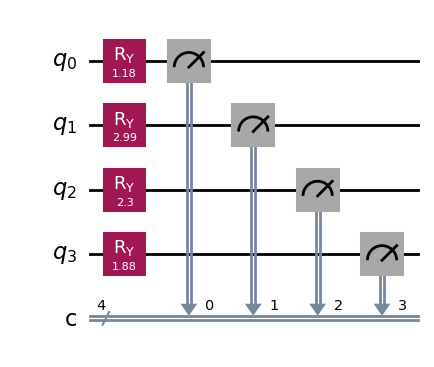

In [247]:
# INDEPENDENT CIRCUIT:
import numpy as np
thetas = np.random.uniform(0, np.pi, size=4)
qc_ind = build_circuit_independent(thetas,measure=True)
qc_ind.draw('mpl')

In [ ]:
# ZZ FeatureMap CIRCUIT:
# from qiskit.circuit.library import zz_feature_map
thetas = np.random.uniform(0, np.pi, size=4)
qc_zzfm = build_zzfeaturemap_circuit(thetas,reps=2,entanglement="full", measure=True)
qc_zzfm.draw('mpl')

: 

In [ ]:
# qc.append(zz_feature_map(2,1),[0,1])
# qc.decompose().draw('mpl')
# qc.assign_parameters({qc.parameters[0]: 0.5, qc.parameters[1]: 0.5})

: 

In [ ]:
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError
from qiskit import transpile
from qiskit.circuit import QuantumCircuit
qc = QuantumCircuit(4,4)
qc.measure([0,1,2,3],[0,1,2,3])
noise_model = create_noise_model(
    mode="experimental_correlated")

sim = AerSimulator(noise_model=noise_model)
qc_t = transpile(qc,sim,optimization_level=0,
    initial_layout=[0,1,2,3])
result = sim.run(qc_t,shots=10000).result()

counts = result.get_counts()

print(counts)

: 

In [ ]:
qc = QuantumCircuit(4,4)
qc.measure([0,1,2,3],[0,1,2,3])

sim = AerSimulator()

qc_t = transpile(qc, sim)

result = sim.run(qc_t, shots=100000).result()

counts = result.get_counts()

p_ideal = counts_to_probs_4q(counts)

print("Ideal:")
print(p_ideal)

p_noisy = apply_correlated_readout_noise(p_ideal)

print("\nNoisy:")
print(np.round(p_noisy,3))

: 

#### Base Functions:

##### Circuits

In [248]:
# import numpy as np
# import matplotlib.pyplot as plt
# from qiskit import QuantumCircuit
# from qiskit.circuit.library import zz_feature_map
# # ============================================================
# # INDEPENDENT CIRCUIT
# def build_circuit_independent(thetas,measure=True,**kwargs):
#     qc = QuantumCircuit(4, 4)
#     for i in range(4):
#         qc.ry(thetas[i], i)
#     if measure:
#         qc.measure([0,1,2,3], [0,1,2,3])
#     return qc
# # ============================================================
# # RZZ CORRELATED CIRCUIT
# def build_correlated_circuit(
#     thetas,theta_rzz=np.pi/2,measure=True,**kwargs):
#     qc = QuantumCircuit(4, 4)
#     # amplitude encoding
#     for i in range(4):
#         qc.ry(thetas[i], i)
#     # basis rotation
#     for i in range(4):
#         qc.h(i)
#     # entangling layer
#     for j in range(4):
#         for k in range(j+1, 4):
#             qc.rzz(theta_rzz, j, k)
#     # return basis
#     for i in range(4):
#         qc.h(i)
#     if measure:
#         qc.measure([0,1,2,3], [0,1,2,3])
#     return qc
# # ============================================================
# # ZZ FEATURE MAP CIRCUIT
# def build_zzfeaturemap_circuit(
#     thetas,reps=1,entanglement="full", measure=True, **kwargs):
#     feature_map = zz_feature_map(feature_dimension=4,
#         reps=reps,entanglement=entanglement)
#     qc = QuantumCircuit(4, 4)
#     qc.compose(feature_map.assign_parameters(thetas),inplace=True )
#     if measure:
#         qc.measure([0,1,2,3], [0,1,2,3])
#     return qc

##### Noise/Readout Erorr/ Save datasets

In [ ]:
# import os
# import numpy as np
# from qiskit_aer import AerSimulator
# from qiskit_aer.noise import NoiseModel, ReadoutError
# from qiskit import transpile
## GLOBAL CONFIG
## ============================================================
# NUM_QUBITS = 4
# DATA_ROOT = "./DataTrain"
# # CIRCUIT REGISTRY
# CIRCUIT_BUILDERS = {"independent": build_circuit_independent,
#     "zz_featuremap": build_zzfeaturemap_circuit,}
# # ============================================================
# # NOISE MODEL REGISTRY
# NOISE_MODES = {"synthetic","experimental_single","experimental_correlated"}
# # ============================================================
# CREATE NOISE MODEL
# def create_noise_model(mode="synthetic",p01=0.05,p10=0.05,
#     single_qubit_dir="./noise_matrix_results",
#     correlated_matrix_path="./noise_matrix_results/noise_matrix_16x16.txt"):
#     """Create noise model.
#     synthetic:
#         Same readout error on all qubits.
#     experimental_single:
#         Uses independent 2x2 assignment matrices
#         extracted from experimental data.
#     experimental_correlated:
#         Uses full correlated 16x16 readout matrix. """
#     noise_model = NoiseModel()
#     # SYNTHETIC
#     if mode == "synthetic":
#         readout_error = ReadoutError([[1-p01, p01],
#                                       [p10, 1-p10] ])
#         for q in range(NUM_QUBITS):
#             noise_model.add_readout_error(readout_error,[q] )
#     # EXPERIMENTAL SINGLE-QUBIT
#     elif mode == "experimental_single":
#         for q in range(NUM_QUBITS):
#             path = os.path.join(single_qubit_dir,
#                 f"assignment_matrix_q{q+1}.txt")
#             A = np.loadtxt(path)
#             readout_error = ReadoutError(A)
#             noise_model.add_readout_error(readout_error,[q])
#     elif mode == "experimental_correlated":
#         # handled manually
#         return None
#     else:
#         raise ValueError(f"Unknown noise mode: {mode}")
#     return noise_model
# APPLY CORRELATED READOUT NOISE
## ============================================================
# def apply_correlated_readout_noise(p_ideal,
#     correlated_matrix_path="./noise_matrix_results/noise_matrix_16x16.txt"):
#     """Apply correlated 16x16 readout assignment matrix.
#     A[i,j] = P(measured=j | prepared=i)
#     Therefore:
#     p_noisy = p_ideal @ A    """
#     A16 = np.loadtxt(correlated_matrix_path)
#     p_noisy = p_ideal @ A16
#     return p_noisy
# # COUNTS -> PROBABILITIES
## ============================================================
# def counts_to_probs_4q(counts):
#     probs = np.zeros(16)
#     for bitstring, count in counts.items():
#         probs[int(bitstring, 2)] = count
#     return probs / np.sum(probs)
# # RUN CIRCUIT
# # ============================================================
# def get_probs(circuit_builder,thetas,noise_model=None,
#     shots=1024,**circuit_kwargs):
#     qc = circuit_builder(thetas,**circuit_kwargs)
#     sim = AerSimulator(noise_model=noise_model)
#     qc_t = transpile(qc, sim)
#     result = sim.run(qc_t,shots=shots).result()
#     counts = result.get_counts()
#     return counts_to_probs_4q(counts)
# # GENERATE DATASET
# # ============================================================
# def generate_dataset(num_samples,circuit_type="independent",
#     noise_mode="synthetic",shots=1024,noise_kwargs=None,circuit_kwargs=None):
#     """ Generate dataset.
#     INPUT:
#     circuit_type:
#         independent
#         zz_featuremap
#     noise_mode:
#         synthetic
#         experimental_single
#         experimental_correlated """
#     if noise_kwargs is None:
#         noise_kwargs = {}
#     if circuit_kwargs is None:
#         circuit_kwargs = {}
#     if circuit_type not in CIRCUIT_BUILDERS:
#         raise ValueError("Unknown circuit type")
#     circuit_builder = CIRCUIT_BUILDERS[circuit_type]
#     X, Y, THETAS  = [], [], []
#     for _ in range(num_samples):
#         thetas = np.random.uniform(0,np.pi, size=NUM_QUBITS )   ######
#         # thetas = np.random.uniform(0,np.pi/4, size=NUM_QUBITS )
#         # CREATE NOISE MODEL
#         # --------------------------------------------
#         if noise_mode == "synthetic":
#             p01 = np.random.uniform(noise_kwargs.get("p01_min", 0.05),
#                 noise_kwargs.get("p01_max", 0.15))
#             p10 = np.random.uniform(noise_kwargs.get("p10_min", 0.05),
#                 noise_kwargs.get("p10_max", 0.15) )
#             noise_model = create_noise_model(mode="synthetic", p01=p01,p10=p10)
#         else:
#             noise_model = create_noise_model(mode=noise_mode)
#         # IDEAL
#         # --------------------------------------------
#         p_ideal = get_probs(circuit_builder,thetas,
#             noise_model=None,shots=shots,**circuit_kwargs)      
#         # NOISY
#         # --------------------------------------------
#         if noise_mode == "experimental_correlated":
#             p_noisy = apply_correlated_readout_noise(p_ideal )
#         else:
#             p_noisy = get_probs(circuit_builder,thetas,
#              noise_model=noise_model,shots=shots,**circuit_kwargs )
#         X.append(p_noisy)
#         Y.append(p_ideal)
#         THETAS.append(thetas)
#     return (np.array(X),np.array(Y), np.array(THETAS))
# # SAVE DATASET
# # ============================================================
# def save_dataset(X,Y,THETAS,split="train",
#     circuit_type="independent",noise_mode="synthetic"):
#     """ Save dataset to:
#      DataTrain/
#         circuit_type/
#             noise_mode/ """
#     save_dir = os.path.join(DATA_ROOT,circuit_type, noise_mode)
#     os.makedirs(save_dir, exist_ok=True)
#     np.savetxt(os.path.join(save_dir, f"X_{split}.txt"),X)
#     np.savetxt(os.path.join(save_dir, f"Y_{split}.txt"),Y )
#     np.savetxt(os.path.join(save_dir, f"theta_{split}.txt"),THETAS)
#     print("\nSaved dataset:")
#     print(save_dir)
# # LOAD DATASET
# # ============================================================
# def load_dataset(split="train",circuit_type="independent",
#     noise_mode="synthetic"):
#     load_dir = os.path.join(DATA_ROOT,circuit_type,noise_mode)
#     X = np.loadtxt(os.path.join(load_dir, f"X_{split}.txt"))
#     Y = np.loadtxt(os.path.join(load_dir, f"Y_{split}.txt"))
#     THETAS = np.loadtxt(os.path.join(load_dir, f"theta_{split}.txt"))
#     return X, Y, THETAS
# # BUILD + SAVE DATASET
# # ============================================================
# def build_and_save_dataset(
#     num_samples,split="train",circuit_type="independent",
#     noise_mode="synthetic",shots=1024,noise_kwargs=None,
#     circuit_kwargs=None):
#     print("GENERATING DATASET")
#     print("================================================")
#     print("Circuit :", circuit_type)
#     print("Noise   :", noise_mode)
#     print("Samples :", num_samples)
#     X, Y, THETAS = generate_dataset(
#         num_samples=num_samples,
#         circuit_type=circuit_type,
#         noise_mode=noise_mode,
#         shots=shots,noise_kwargs=noise_kwargs,
#         circuit_kwargs=circuit_kwargs)
#     save_dataset(X,Y,THETAS,
#         split=split,circuit_type=circuit_type,noise_mode=noise_mode)
#     return X, Y, THETAS

##### Evaluate Model

In [249]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, TensorDataset
# # Metrices 
# def kl_divergence(p, q):
#     return np.sum(p * np.log((p + 1e-10)/(q + 1e-10)))
# def fidelity(p, q):
#     return (np.sum(np.sqrt(p*q)))**2
# def l1_error(p, q):
#     return np.sum(np.abs(p-q))
# def evaluate_model(model, X, Y):
#     model.eval()
#     fids,l1s, kls  = [], [], []
#     with torch.no_grad():
#         preds = model(
#             torch.tensor(X, dtype=torch.float32)).numpy()
#     for pred, true in zip(preds, Y):
#         fids.append(fidelity(true, pred))
#         l1s.append(l1_error(true, pred))
#         kls.append(kl_divergence(true, pred))
#     return {"fidelity_mean": np.mean(fids),
#         # "fidelity_std":  np.std(fids),
#         "l1_mean": np.mean(l1s),
#         # "l1_std":  np.std(l1s),
#         "kl_mean": np.mean(kls),
#         # "kl_std":  np.std(kls),
#         "all_fidelities": np.array(fids),
#         "all_l1": np.array(l1s),
#         "all_kl": np.array(kls) }

##### Compare results

In [250]:
# import numpy as np
# import torch
# import matplotlib.pyplot as plt
# def visualize_aligned_samples(
#     model, X_syn, Y_syn, X_single, Y_single,
#     X_corr, Y_corr,n_samples=3,seed=42):

#     np.random.seed(seed)
#     model.eval()
#     # 🎯 shared indices across ALL datasets
#     base_len = len(X_syn)
#     indices = np.random.choice(base_len, n_samples, replace=False)
#     print(f"Shared indices: {indices}")
#     for idx in indices:
#         fig, axes = plt.subplots(1, 3, figsize=(18, 4))
#         datasets = [("Synthetic", X_syn, Y_syn, axes[0]),
#             ("Experimental Single", X_single, Y_single, axes[1]),
#             ("Experimental Correlated", X_corr, Y_corr, axes[2]),   ]
#         for title, X, Y, ax in datasets:
#             x = torch.tensor( X[idx], dtype=torch.float32 ).unsqueeze(0)
#             with torch.no_grad():
#                 pred = model(x).numpy().flatten()
#             true = Y[idx]
#             noisy = X[idx]
#             f = fidelity(true, pred)
#             x_axis = np.arange(len(true))
#             ax.bar(x_axis - 0.25, true, width=0.25, label="Ideal")
#             ax.bar(x_axis, noisy, width=0.25, label="Noisy", alpha=0.6)
#             ax.bar(x_axis + 0.25, pred, width=0.25, label="Predicted")
#             ax.set_title(f"{title}\nFidelity = {f:.4f}")
#             ax.set_xlabel("State Index")
#             ax.set_ylabel("Probability")
#             ax.grid()
#             ax.legend()
#         plt.suptitle(f"Aligned Sample Index = {idx}", fontsize=14)
#         plt.tight_layout()
#         plt.show()


##### Metrices 

In [ ]:
# import numpy as np

# def compute_metrics(preds, Y):
#     fidelities = []
#     l1s = []
#     kls = []
#     for i in range(len(preds)):
#         p = preds[i]
#         y = Y[i]
#         fid = (np.sum(np.sqrt(p * y))) ** 2
#         l1 = np.sum(np.abs(p - y))
#         kl = np.sum(y * np.log((y + 1e-10) / (p + 1e-10)))
#         fidelities.append(fid)
#         l1s.append(l1)
#         kls.append(kl)

#     return {"FidelityMean": np.mean(fidelities),
#         "L1Mean": np.mean(l1s),
#         "KLMean": np.mean(kls),  }

# def evaluate_phase(model, X_test, Y_test):
#     X_test = torch.tensor( X_test,
#         dtype=torch.float32 )
#     model.eval()
#     with torch.no_grad():
#         preds = model(X_test).numpy()
#     return compute_metrics(preds, Y_test)

##### Dashboard/ Organize Outputs

In [ ]:
# from collections import defaultdict
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# # ============================================================
# # STORAGE
# EXPERIMENTS = defaultdict(list)
# # ============================================================
# # REGISTER RESULTS (no structural change, فقط تمیزتر)

# def register_results(experiments_dict,
#                      circuit,
#                      training_noise,
#                      noise_mode,
#                      metrics):
#     key = (circuit, training_noise)
#     experiments_dict[key].append({
#         "Dataset": noise_mode,
#         **metrics})
# # ============================================================
# # METRIC-AGNOSTIC CONFIG
# # ------------------------------------------------------------
# # هر سه معیار به صورت یکسان پشتیبانی می‌شوند و فقط یک‌بار محاسبه و
# # ذخیره می‌شوند؛ تغییر معیارِ نمایش هیچ بازاجرایی لازم ندارد.
# METRICS = ["FidelityMean", "L1Mean", "KLMean"]

# # نگاشت نام داخلی dataset به برچسب نمایشی
# DATASET_LABELS = {
#     "synthetic": "Synthetic",
#     "experimental_single": "Experimental Single",
#     "experimental_correlated": "Experimental Correlated",
# }
# DATASET_ORDER = ["Synthetic", "Experimental Single", "Experimental Correlated"]
# TRAINING_ORDER = ["No Training", "Synthetic",
#                   "Experimental Single", "Experimental Correlated"]

# # برای هر معیار: آیا مقدار بزرگ‌تر بهتر است؟ + colormap مناسب
# # Fidelity → بزرگ‌تر بهتر | L1, KL → کوچک‌تر بهتر (colormap معکوس)
# METRIC_META = {
#     "FidelityMean": {"higher_is_better": True,  "cmap": "viridis",
#                      "title": "Fidelity (higher = better)"},
#     "L1Mean":       {"higher_is_better": False, "cmap": "viridis_r",
#                      "title": "L1 Error (lower = better)"},
#     "KLMean":       {"higher_is_better": False, "cmap": "viridis_r",
#                      "title": "KL Divergence (lower = better)"},
# }

# # ============================================================
# # BUILD SUMMARY DF (همه‌ی معیارها را نگه می‌دارد)
# # خروجی: قالب wide با ستون‌هایی مثل "Synthetic_FidelityMean", ...
# def build_summary_df(experiments):
#     rows = []
#     for (circuit, training_noise), results_list in experiments.items():
#         row = {"Circuit": circuit, "Training Noise": training_noise}
#         for r in results_list:
#             dataset = DATASET_LABELS.get(r["Dataset"], r["Dataset"])
#             for metric in METRICS:
#                 if metric in r:
#                     row[f"{dataset}_{metric}"] = r[metric]
#         rows.append(row)
#     df = pd.DataFrame(rows).set_index(["Circuit", "Training Noise"])
#     # ستون‌ها را به ترتیب dataset × metric مرتب کن
#     ordered_cols = [f"{ds}_{m}" for ds in DATASET_ORDER for m in METRICS]
#     df = df[[c for c in ordered_cols if c in df.columns]]
#     return df

# # ============================================================
# # استخراج نمای یک معیار: جدولی با ستون‌های dataset برای معیار انتخابی
# def metric_view(summary_df, metric):
#     if metric not in METRICS:
#         raise ValueError(f"metric باید یکی از {METRICS} باشد، نه {metric!r}")
#     cols = [f"{ds}_{metric}" for ds in DATASET_ORDER]
#     existing = [c for c in cols if c in summary_df.columns]
#     view = summary_df[existing].copy()
#     # حذف پسوند معیار از نام ستون‌ها برای خوانایی
#     view.columns = [c.rsplit("_", 1)[0] for c in existing]
#     return view

# # ============================================================
# # جدول خلاصه برای یک معیار (با ترتیب ثابت سطرها)
# def show_summary_table(summary_df, metric="FidelityMean", round_digits=3):
#     view = metric_view(summary_df, metric)
#     # ترتیب سطرها: به ازای هر مدار، ترتیب آموزش‌ها ثابت
#     circuits = summary_df.index.get_level_values(0).unique()
#     desired = [(c, t) for c in circuits for t in TRAINING_ORDER]
#     desired = [k for k in desired if k in view.index]
#     view = view.reindex(desired)
#     meta = METRIC_META.get(metric, {})
#     print(f"\n================ {metric} | {meta.get('title', metric)} ================")
#     print(view.round(round_digits).to_string())
#     return view

# # ============================================================
# # DASHBOARD (CIRCUIT-CENTRIC, METRIC-AGNOSTIC)
# def full_dashboard(summary_df, metric="FidelityMean"):
#     meta = METRIC_META.get(metric, {"cmap": "viridis", "title": metric})
#     circuits = summary_df.index.get_level_values(0).unique()
#     for circuit in circuits:
#         print(f"\n\n================ {circuit} | {metric} ================")
#         df_c = metric_view(summary_df.xs(circuit, level=0), metric)
#         df_c = df_c.reindex([t for t in TRAINING_ORDER if t in df_c.index])
#         plt.figure(figsize=(8, 5))
#         sns.heatmap(df_c, annot=True, fmt=".3f", cmap=meta["cmap"])
#         plt.title(f"{circuit} | {meta['title']}")
#         plt.xlabel("Test Noise Type")
#         plt.ylabel("Training Condition")
#         plt.tight_layout()
#         plt.show()

# # ============================================================
# # داشبورد ترکیبی: هر سه معیار کنار هم برای یک مدار (یک ردیف heatmap)
# def metrics_dashboard(summary_df, metrics=None):
#     metrics = metrics or METRICS
#     circuits = summary_df.index.get_level_values(0).unique()
#     for circuit in circuits:
#         fig, axes = plt.subplots(1, len(metrics),
#                                  figsize=(6 * len(metrics), 5))
#         if len(metrics) == 1:
#             axes = [axes]
#         for ax, metric in zip(axes, metrics):
#             meta = METRIC_META.get(metric, {"cmap": "viridis", "title": metric})
#             df_c = metric_view(summary_df.xs(circuit, level=0), metric)
#             df_c = df_c.reindex([t for t in TRAINING_ORDER if t in df_c.index])
#             sns.heatmap(df_c, annot=True, fmt=".3f", cmap=meta["cmap"], ax=ax)
#             ax.set_title(meta["title"])
#             ax.set_xlabel("Test Noise Type")
#             ax.set_ylabel("Training Condition")
#         fig.suptitle(f"{circuit}", fontsize=15)
#         plt.tight_layout()
#         plt.show()

# # ============================================================
# # نمایش همه‌ی جدول‌ها یک‌جا
# def show_all_summary_tables(summary_df, round_digits=3):
#     for metric in METRICS:
#         show_summary_table(summary_df, metric, round_digits)

In [ ]:

# def run_all_tests(model, experiments,
#     circuit,training_noise, test_sets):
#     for noise_mode, (X_test, Y_test) in test_sets.items():
#         metrics = evaluate_phase(model, X_test, Y_test )
#         register_results( experiments,
#             circuit=circuit, training_noise=training_noise,
#             noise_mode=noise_mode, metrics=metrics )

- I generated these datasets:
    - independent circuit with all three noise modes: synthetic, exprimental single and correlated
    - zzfeaturmap circuit with all noises. 


### Run All Phases

#### Phase 0 / Baseline 
<!-- prediction = X_noisy
target     = Y_ideal -->


Identity Model

In [251]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
class IdentityModel(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return x
model_base = IdentityModel()     # For synthetic circuit 
model_base_zz = IdentityModel()  # For zz feature circuit

In [252]:
import pandas as pd
from src.evaluation import evaluate_model

results_0 = {}
noise_modes = ["synthetic","experimental_single",
    "experimental_correlated"]
for noise_mode in noise_modes:
    X_test, Y_test, TH_test = load_dataset(
        split="test", circuit_type="independent",
        noise_mode=noise_mode)
    results_0[noise_mode] = evaluate_model(
        model_base,  X_test, Y_test)
rows = []
for noise_mode, metrics in results_0.items():
    rows.append({"Dataset": noise_mode,
        "FidelityMean": metrics["fidelity_mean"],
        "L1 Mean": metrics["l1_mean"],"KL Mean": metrics["kl_mean"] })
df_0 = pd.DataFrame(rows)
print("phase 0 (no training): Independent circuit")
print("==========================================================")
print(df_0.round(3))

phase 0 (no training): Independent circuit
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.907    0.367    0.137
1      experimental_single         0.768    0.707    0.386
2  experimental_correlated         0.763    0.714    0.398


#### Phase 1
<!-- - TRAIN:
    - independent + synthetic

- VALIDATION:
    - independent + synthetic

- TEST:
    - independent + all noises     -->

Train on independent circuit -Ry- using synthetic noise models and test on all noises.

In [253]:
X_train_1, Y_train_1, TH_train_1 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="synthetic")
X_val_1, Y_val_1, TH_val_1 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="synthetic")
# Test — synthetic
X_test_syn_1, Y_test_syn_1, TH_test_syn_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="synthetic")
# Test — experimental single
X_test_single_1, Y_test_single_1, TH_test_single_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="experimental_single")
# Test — experimental correlated
X_test_corr_1, Y_test_corr_1, TH_test_corr_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="experimental_correlated")

In [254]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_1, dtype=torch.float32),
        torch.tensor(Y_train_1, dtype=torch.float32)),
        batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_1, dtype=torch.float32),
        torch.tensor(Y_val_1, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False)

In [255]:
import torch
import torch.nn as nn
class MLP_4Q(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 16),
            nn.Softmax(dim=1)
            # nn.LogSoftmax(dim=1)
              )
    def forward(self, x):
        return self.net(x)

In [256]:
model_phase1 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase1.parameters(),
    lr=1e-3)
EPOCHS = 71
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase1(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase1(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

# model_phase1 = MLP_4Q()
# # criterion = nn.KLDivLoss(reduction="batchmean")
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(
#     model_phase1.parameters(),
#     lr=1e-3)
# EPOCHS = 101
# train_losses = []
# val_losses = []
# for epoch in range(EPOCHS):
#     # TRAIN
#     # =====================================================
#     model_phase1.train()
#     running_loss = 0.0
#     for xb, yb in train_loader:
#         optimizer.zero_grad()
#         preds = model_phase1(xb)
#         loss = criterion(preds, yb)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#     train_loss = running_loss / len(train_loader)
#     # VALIDATION
#     # =====================================================
#     model_phase1.eval()
#     val_running_loss = 0.0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             preds = model_phase1(xb)
#             loss = criterion(preds, yb)
#             val_running_loss += loss.item()
#     val_loss = val_running_loss / len(val_loader)
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     if epoch % 10 == 0:
#         print( f"Epoch {epoch} | "
#             f"Train Loss = {train_loss:.6f} | "
#             f"Val Loss = {val_loss:.6f}" )

Epoch 0 | Train Loss = 0.8417 | Val Loss = 0.1330
Epoch 10 | Train Loss = 0.0522 | Val Loss = 0.0535
Epoch 20 | Train Loss = 0.0385 | Val Loss = 0.0402
Epoch 30 | Train Loss = 0.0341 | Val Loss = 0.0356
Epoch 40 | Train Loss = 0.0334 | Val Loss = 0.0373
Epoch 50 | Train Loss = 0.0331 | Val Loss = 0.0355
Epoch 60 | Train Loss = 0.0328 | Val Loss = 0.0344
Epoch 70 | Train Loss = 0.0329 | Val Loss = 0.0341


In [257]:
results_1 = {}
results_1["synthetic"] = evaluate_model(
    model_phase1,X_test_syn_1,Y_test_syn_1)
results_1["experimental_single"] = evaluate_model(
    model_phase1,X_test_single_1,Y_test_single_1)
results_1["experimental_correlated"] = evaluate_model(
    model_phase1, X_test_corr_1, Y_test_corr_1)
import pandas as pd
rows = []
for name, res in results_1.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_1 = pd.DataFrame(rows)
print('==========================================================')
print("phase 1 (training): circuit: Independent, Noise: Synthetic")
print(df_1)

phase 1 (training): circuit: Independent, Noise: Synthetic
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.979    0.147    0.034
1      experimental_single         0.836    0.567    0.268
2  experimental_correlated         0.828    0.585    0.285


Shared indices: [1116]


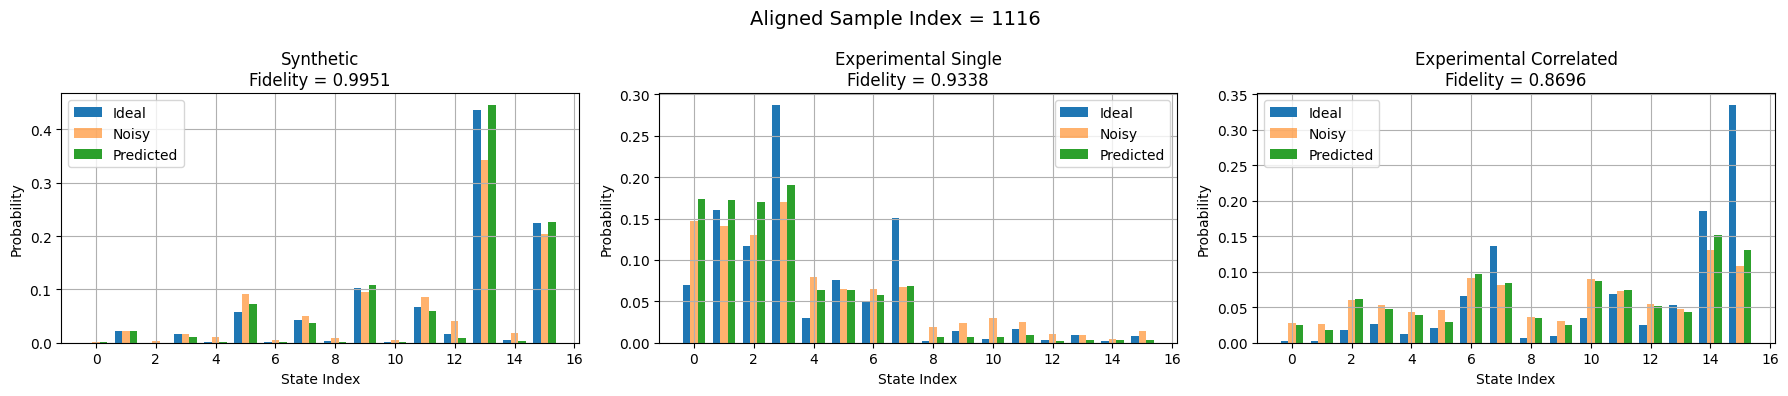

In [258]:
visualize_aligned_samples(model_phase1,
    X_test_syn_1, Y_test_syn_1,
    X_test_single_1, Y_test_single_1,
    X_test_corr_1, Y_test_corr_1,
    n_samples=1)


##### TEST fidelity befor TRAINING

In [259]:
# Fidelity before executing the training! 
raw_fidelity = np.mean([
    fidelity(Y_test_syn_1[i], X_test_syn_1[i])
    for i in range(len(X_test_syn_1))])
print(raw_fidelity)
raw_fidelity = np.mean([
    fidelity(Y_test_single_1[i], X_test_single_1[i])
    for i in range(len(X_test_syn_1))])

print(raw_fidelity)
raw_fidelity = np.mean([
    fidelity(Y_test_corr_1[i], X_test_corr_1[i])
    for i in range(len(X_test_syn_1))])
print(raw_fidelity)

0.9072323893272527
0.7676126563131969
0.7628629197344488


#### Phase 2

phase 2_0:
Ry Circuit and train experimental single!

In [260]:
X_train_2, Y_train_2, TH_train_2 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="experimental_single")
X_val_2, Y_val_2, TH_val_2 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="experimental_single")
# Test — synthetic
# As above for independent circuit

In [261]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_2, dtype=torch.float32),
        torch.tensor(Y_train_2, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_2, dtype=torch.float32),
        torch.tensor(Y_val_2, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [267]:
model_phase2_0 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase2_0.parameters(),
    lr=1e-3)
EPOCHS = 71
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase2_0.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase2_0(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase2_0.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase2_0(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

# model_phase2_0 = MLP_4Q()
# # criterion = nn.KLDivLoss(reduction="batchmean")
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(
#     model_phase2_0.parameters(),
#     lr=1e-3)
# EPOCHS = 101
# train_losses = []
# val_losses = []
# for epoch in range(EPOCHS):
#     # TRAIN
#     # =====================================================
#     model_phase2_0.train()
#     running_loss = 0.0
#     for xb, yb in train_loader:
#         optimizer.zero_grad()
#         preds = model_phase2_0(xb)
#         loss = criterion(preds, yb)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#     train_loss = running_loss / len(train_loader)
#     # VALIDATION
#     # =====================================================
#     model_phase2_0.eval()
#     val_running_loss = 0.0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             preds = model_phase2_0(xb)
#             loss = criterion(preds, yb)
#             val_running_loss += loss.item()
#     val_loss = val_running_loss / len(val_loader)
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     if epoch % 10 == 0:
#         print( f"Epoch {epoch} | "
#             f"Train Loss = {train_loss:.6f} | "
#             f"Val Loss = {val_loss:.6f}" )

Epoch 0 | Train Loss = 0.9625 | Val Loss = 0.3841
Epoch 10 | Train Loss = 0.0497 | Val Loss = 0.0500
Epoch 20 | Train Loss = 0.0446 | Val Loss = 0.0450
Epoch 30 | Train Loss = 0.0383 | Val Loss = 0.0390
Epoch 40 | Train Loss = 0.0323 | Val Loss = 0.0322
Epoch 50 | Train Loss = 0.0271 | Val Loss = 0.0292
Epoch 60 | Train Loss = 0.0240 | Val Loss = 0.0250
Epoch 70 | Train Loss = 0.0182 | Val Loss = 0.0184


In [ ]:
# # Plot 
# plt.figure(figsize=(4,2))
# plt.plot(train_losses, label="Train")
# plt.plot(val_losses,
#          label="Validation Experimental Single")
# plt.xlabel("Epoch")
# plt.ylabel("KL Loss")
# plt.title("Training Curve (Circuit: Ry, Noise: Synthetic)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [268]:
results_2 = {}
results_2["synthetic"] = evaluate_model(
    model_phase2_0,X_test_syn_1,Y_test_syn_1)
results_2["experimental_single"] = evaluate_model(
    model_phase2_0,X_test_single_1,Y_test_single_1)
results_2["experimental_correlated"] = evaluate_model(
    model_phase2_0, X_test_corr_1, Y_test_corr_1)
import pandas as pd
rows = []
for name, res in results_2.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_2_0 = pd.DataFrame(rows)
print("phase 2_0: circuit Independent, Noise: Single")
print('==========================================================')
print(df_2_0)

phase 2_0: circuit Independent, Noise: Single
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.862    0.488    0.435
1      experimental_single         0.969    0.203    0.060
2  experimental_correlated         0.988    0.094    0.018


Shared indices: [1116]


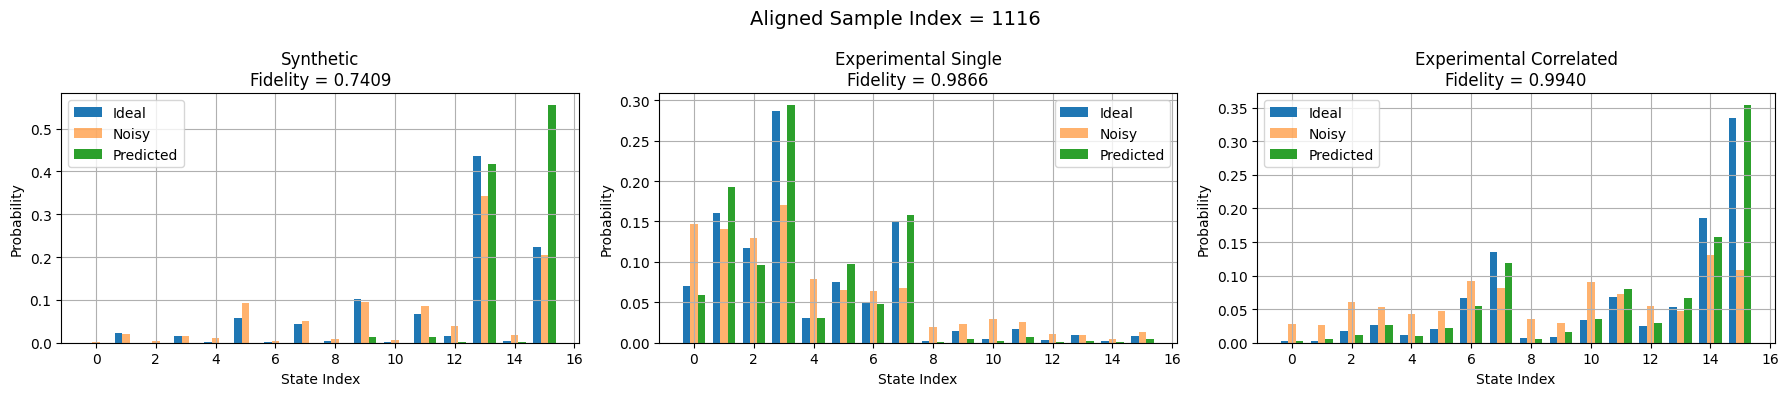

In [269]:
visualize_aligned_samples(model_phase2_0,

    X_test_syn_1, Y_test_syn_1,
    X_test_single_1, Y_test_single_1,
    X_test_corr_1, Y_test_corr_1,
    n_samples=1)

##### phase 2_1:
Ry Circuit and train correlated datasets!

In [270]:
X_train_2_1, Y_train_2_1, TH_train_2_1 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="experimental_correlated")
X_val_2_1, Y_val_2_1, TH_val_2_1 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="experimental_correlated")
# Test — synthetic
# AS sam as above for ind circuit

In [271]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_2_1, dtype=torch.float32),
        torch.tensor(Y_train_2_1, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_2_1, dtype=torch.float32),
        torch.tensor(Y_val_2_1, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [272]:
model_phase2_1 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase2_1.parameters(),
    lr=1e-3)
EPOCHS = 71
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase2_1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase2_1(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase2_1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase2_1(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

# model_phase2_1 = MLP_4Q()
# # criterion = nn.KLDivLoss(reduction="batchmean")
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(
#     model_phase2_1.parameters(),
#     lr=1e-3)
# EPOCHS = 101
# train_losses = []
# val_losses = []
# for epoch in range(EPOCHS):
#     # TRAIN
#     # =====================================================
#     model_phase2_1.train()
#     running_loss = 0.0
#     for xb, yb in train_loader:
#         optimizer.zero_grad()
#         preds = model_phase2_1(xb)
#         loss = criterion(preds, yb)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#     train_loss = running_loss / len(train_loader)
#     # VALIDATION
#     # =====================================================
#     model_phase2_1.eval()
#     val_running_loss = 0.0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             preds = model_phase2_1(xb)
#             loss = criterion(preds, yb)
#             val_running_loss += loss.item()
#     val_loss = val_running_loss / len(val_loader)
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     if epoch % 10 == 0:
#         print( f"Epoch {epoch} | "
#             f"Train Loss = {train_loss:.6f} | "
#             f"Val Loss = {val_loss:.6f}" )



Epoch 0 | Train Loss = 0.9886 | Val Loss = 0.3596
Epoch 10 | Train Loss = 0.0515 | Val Loss = 0.0530
Epoch 20 | Train Loss = 0.0488 | Val Loss = 0.0506
Epoch 30 | Train Loss = 0.0433 | Val Loss = 0.0463
Epoch 40 | Train Loss = 0.0362 | Val Loss = 0.0370
Epoch 50 | Train Loss = 0.0342 | Val Loss = 0.0354
Epoch 60 | Train Loss = 0.0334 | Val Loss = 0.0347
Epoch 70 | Train Loss = 0.0282 | Val Loss = 0.0299


In [273]:
results_2_1 = {}
results_2_1["synthetic"] = evaluate_model(
    model_phase2_1,X_test_syn_1,Y_test_syn_1)
results_2_1["experimental_single"] = evaluate_model(
    model_phase2_1,X_test_single_1,Y_test_single_1)
results_2_1["experimental_correlated"] = evaluate_model(
    model_phase2_1, X_test_corr_1, Y_test_corr_1)
import pandas as pd
rows = []
for name, res in results_2_1.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_2_1 = pd.DataFrame(rows)
print("phase 2_1: circuit Independent, Noise: correlated")
print('==========================================================')
print(df_2_1)

phase 2_1: circuit Independent, Noise: correlated
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.866    0.482    0.425
1      experimental_single         0.965    0.208    0.065
2  experimental_correlated         0.980    0.128    0.029


Shared indices: [1116]


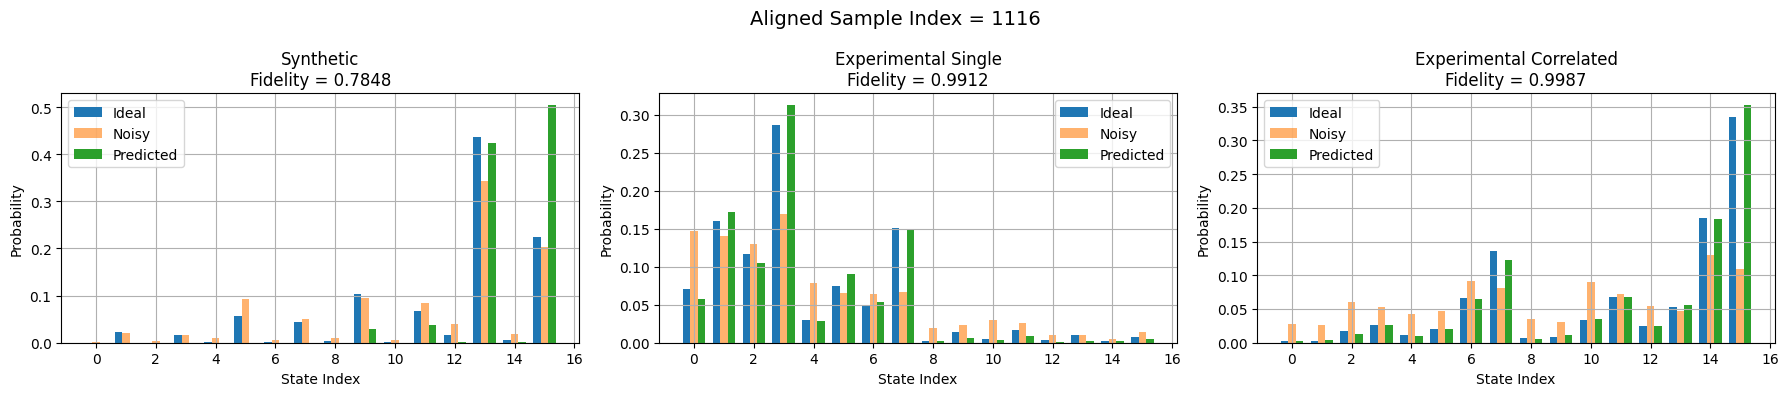

In [274]:
visualize_aligned_samples(model_phase2_1,
    X_test_syn_1, Y_test_syn_1,
    X_test_single_1, Y_test_single_1,
    X_test_corr_1, Y_test_corr_1,
    n_samples=1)

#### Phase 3_0 
- TRAIN:
    - zzfeaturemap + synthetic  


- VALIDATION:
    - zzfeaturemap + synthetic

- TEST:
    - zzfeaturemap + experimental_single
    - zzfeaturemap + experimental_correlated 
    - zzfeaturemap  + synthetic 

In [275]:
X_train_30, Y_train_30, TH_train_30 = load_dataset(
    split="train",circuit_type="zz_featuremap",
    noise_mode="synthetic")
X_val_30, Y_val_30, TH_val_30 = load_dataset(
    split="validation",circuit_type="zz_featuremap",
    noise_mode="synthetic")
# Test 
X_test_syn_30, Y_test_syn_30, TH_test_syn_30 = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="synthetic")
X_test_single_30, Y_test_single_30, TH_test_single_30 = load_dataset(
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single")
X_test_corr_30, Y_test_corr_30, TH_test_corr_30 = load_dataset(
    split="test",circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [276]:
# Fidelity before executing the training! 
raw_fidelity30 = np.mean([
    fidelity(Y_test_syn_30[i], X_test_syn_30[i])
    for i in range(len(X_test_syn_30))])
print(raw_fidelity30)
raw_fidelity = np.mean([
    fidelity(Y_test_single_30[i], X_test_single_30[i])
    for i in range(len(X_test_single_30))])

print(raw_fidelity30)
raw_fidelity30 = np.mean([
    fidelity(Y_test_corr_30[i], X_test_corr_30[i])
    for i in range(len(X_test_corr_30))])
print(raw_fidelity30)

0.9380133486414691
0.9380133486414691
0.8607546498332759


In [277]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_30, dtype=torch.float32),
        torch.tensor(Y_train_30, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_30, dtype=torch.float32),
        torch.tensor(Y_val_30, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [278]:
model_phase3_0 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase3_0.parameters(),
    lr=1e-3)
EPOCHS = 71
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_0.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_0(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase3_0.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_0(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.4910 | Val Loss = 0.4714
Epoch 10 | Train Loss = 0.1139 | Val Loss = 0.1141
Epoch 20 | Train Loss = 0.0669 | Val Loss = 0.0691
Epoch 30 | Train Loss = 0.0533 | Val Loss = 0.0564
Epoch 40 | Train Loss = 0.0479 | Val Loss = 0.0517
Epoch 50 | Train Loss = 0.0458 | Val Loss = 0.0508
Epoch 60 | Train Loss = 0.0445 | Val Loss = 0.0489
Epoch 70 | Train Loss = 0.0435 | Val Loss = 0.0493


In [279]:
results_30 = {}
results_30["synthetic"] = evaluate_model(
    model_phase3_0,X_test_syn_30,Y_test_syn_30)
results_30["experimental_single"] = evaluate_model(
    model_phase3_0,X_test_single_30,Y_test_single_30)
results_30["experimental_correlated"] = evaluate_model(
    model_phase3_0, X_test_corr_30, Y_test_corr_30)
import pandas as pd
rows = []
for name, res in results_30.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_3_0 = pd.DataFrame(rows)
print("phase 3_0: circuit zz, Noise: synthetic")
print('==========================================================')
print(df_3_0)

phase 3_0: circuit zz, Noise: synthetic
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.973    0.208    0.049
1      experimental_single         0.892    0.475    0.192
2  experimental_correlated         0.902    0.455    0.177


Shared indices: [1116]


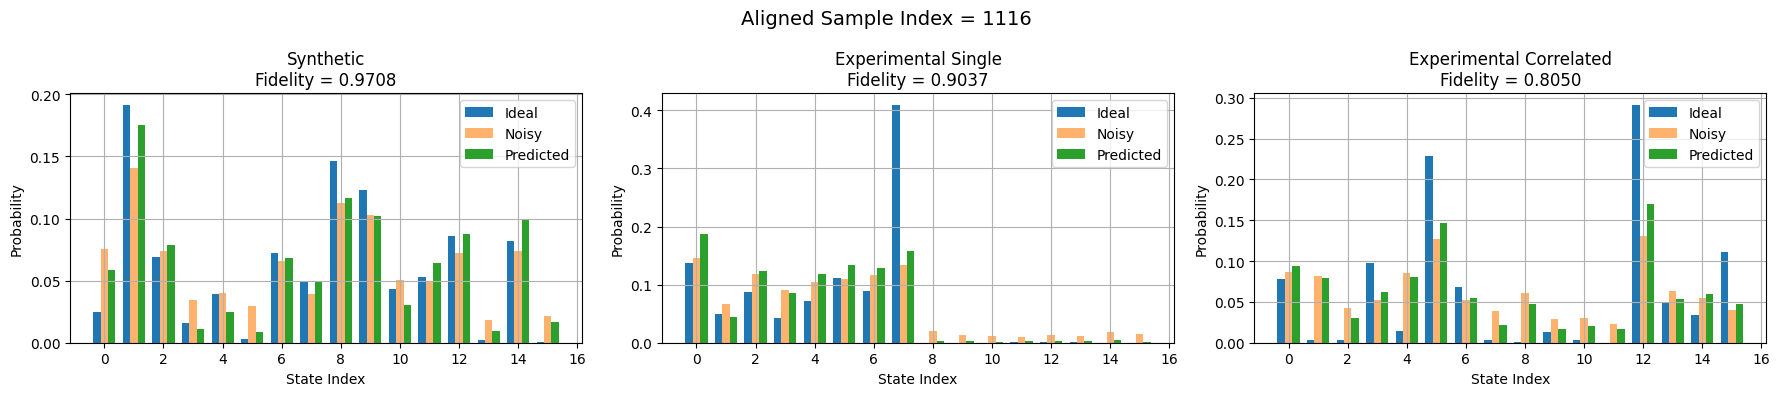

In [280]:
visualize_aligned_samples(
    model_phase3_0,

    X_test_syn_30, Y_test_syn_30,
    X_test_single_30, Y_test_single_30,
    X_test_corr_30, Y_test_corr_30,

    n_samples=1)

#### Phase 3_1 
- TRAIN:
    - zzfeaturemap + experimental_single  


- VALIDATION:
    - zzfeaturemap + experimental_single

- TEST:
    - zzfeaturemap + experimental_single
    - zzfeaturemap + experimental_correlated 
    - independent  + synthetic 

In [ ]:
X_train_31, Y_train_31, TH_train_31 = load_dataset(
    split="train",circuit_type="zz_featuremap",
    noise_mode="experimental_single")   
X_val_31, Y_val_31, TH_val_31 = load_dataset(
    split="validation",circuit_type="zz_featuremap",
    noise_mode="experimental_single")
# Test 
X_test_syn_31, Y_test_syn_31, TH_test_syn_31 = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="synthetic")
X_test_single_31, Y_test_single_31, TH_test_single_31 = load_dataset(
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single")
X_test_corr_31, Y_test_corr_31, TH_test_corr_31 = load_dataset(
    split="test",circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [282]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_31, dtype=torch.float32),
        torch.tensor(Y_train_31, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_31, dtype=torch.float32),
        torch.tensor(Y_val_31, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [283]:
model_phase3_1 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase3_1.parameters(),
    lr=1e-3)
EPOCHS = 71
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_1(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase3_1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_1(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.4891 | Val Loss = 0.4572
Epoch 10 | Train Loss = 0.2194 | Val Loss = 0.2170
Epoch 20 | Train Loss = 0.1591 | Val Loss = 0.1567
Epoch 30 | Train Loss = 0.1362 | Val Loss = 0.1330
Epoch 40 | Train Loss = 0.1213 | Val Loss = 0.1196
Epoch 50 | Train Loss = 0.1108 | Val Loss = 0.1104
Epoch 60 | Train Loss = 0.1027 | Val Loss = 0.1029
Epoch 70 | Train Loss = 0.0992 | Val Loss = 0.0990


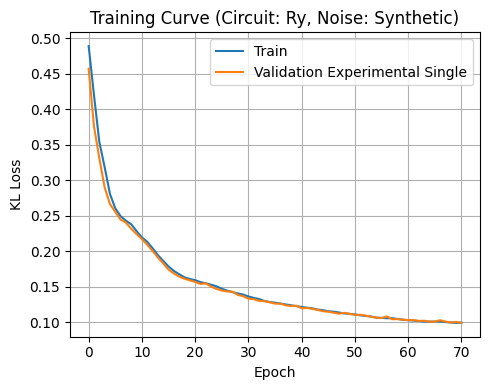

In [284]:
# Plot 
plt.figure(figsize=(5,4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses,
         label="Validation Experimental Single")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("Training Curve (Circuit: Ry, Noise: Synthetic)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [285]:
results_31 = {}
results_31["synthetic"] = evaluate_model(
    model_phase3_1,X_test_syn_31,Y_test_syn_31)
results_31["experimental_single"] = evaluate_model(
    model_phase3_1,X_test_single_31,Y_test_single_31)
results_31["experimental_correlated"] = evaluate_model(
    model_phase3_1, X_test_corr_31, Y_test_corr_31)
import pandas as pd
rows = []
for name, res in results_31.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_3_1 = pd.DataFrame(rows)
print("phase 3_1: circuit zz, Noise: single")
print('==========================================================')
print(df_3_1)

phase 3_1: circuit zz, Noise: single
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.883    0.539    0.267
1      experimental_single         0.942    0.315    0.104
2  experimental_correlated         0.950    0.297    0.088


Shared indices: [1116]


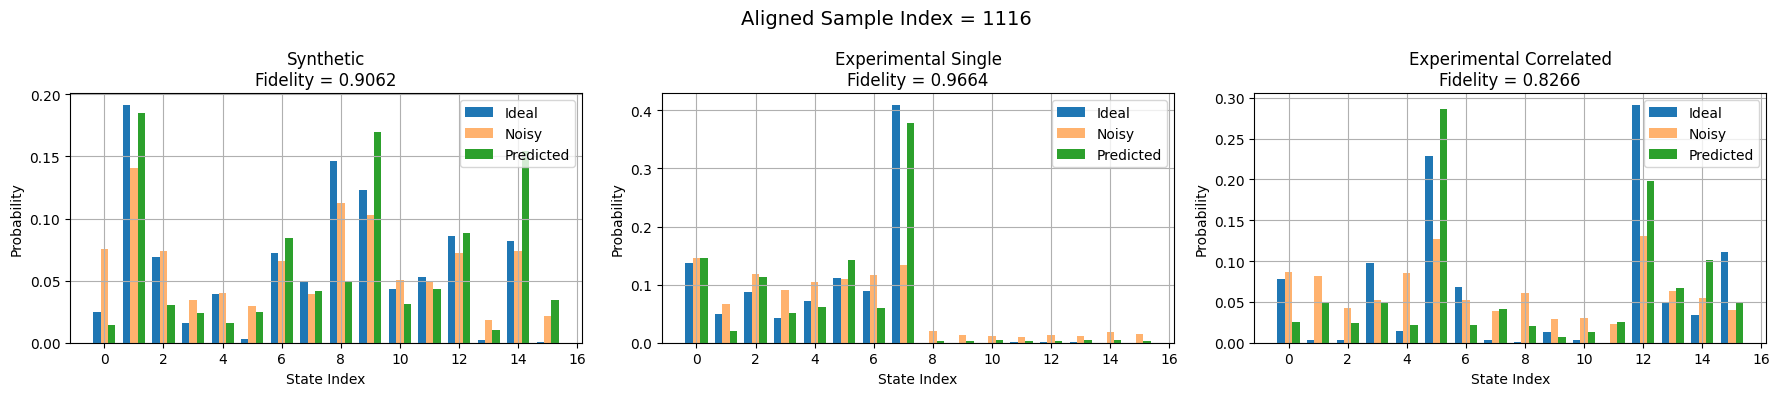

In [286]:
visualize_aligned_samples(model_phase3_1,
    X_test_syn_31, Y_test_syn_31,
    X_test_single_31, Y_test_single_31,
    X_test_corr_31, Y_test_corr_31,
    n_samples=1)

In [ ]:
# # if the noise even excecuted? 
# thetas = np.random.uniform(0,np.pi,4)

# p_ideal = get_probs(build_zzfeaturemap_circuit,
#     thetas, noise_model=None)

# p_noisy = get_probs(
#     build_zzfeaturemap_circuit,
#     thetas, noise_model=create_noise_model(
#         mode="experimental_single"))

# print(fidelity(p_ideal,p_noisy))
# print(np.max(np.abs(p_ideal-p_noisy)))

In [287]:
print(np.mean(np.max(Y_test_single_31, axis=1)))
print(np.mean(np.max(X_test_single_31, axis=1)))

0.24460416666666668
0.15230729166666668


In [288]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)

purity_zz = np.mean([np.sum(y2**2) for y2 in Y_test_corr_31])
print("purity_zz",purity_zz)

purity_ind 0.323609567006429
purity_zz 0.14051694997151692


#### Phase 3_2
- train:
    - zz_featuremap + experimental_correlated
- VALIDATION:
    - zzfeaturemap + experimental_single
- TEST:
    - zzfeaturemap + experimental_single
    - zzfeaturemap + experimental_correlated 
    - zzfeaturemap  + synthetic 


In [289]:
X_train_32, Y_train_32, TH_train_32 = load_dataset(
    split="train", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

X_val_32, Y_val_32, TH_val_32 = load_dataset(
    split="validation", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

X_test_syn_32, Y_test_syn_32, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="synthetic")
X_test_single_32, Y_test_single_32, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_single")

X_test_corr_32, Y_test_corr_32, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [290]:
# Fidelity before executing the training! 
raw_fidelity2 = np.mean([
    fidelity(Y_test_syn_32[i], X_test_syn_32[i])
    for i in range(len(X_test_syn_32))])
print(raw_fidelity2)
raw_fidelity2 = np.mean([
    fidelity(Y_test_single_32[i], X_test_single_32[i])
    for i in range(len(X_test_single_32))])

print(raw_fidelity2)
raw_fidelity2 = np.mean([
    fidelity(Y_test_corr_32[i], X_test_corr_32[i])
    for i in range(len(X_test_corr_32))])
print(raw_fidelity2)

0.9380133486414691
0.8532504710227674
0.8607546498332759


In [291]:
# check fidelity without traing
fids_raw1 = []
fids_raw2 = []

fids_raw2 = np.mean([
    fidelity(Y_test_syn_32[i], X_test_syn_32[i])
    for i in range(len(X_test_syn_32))])

for i in range(len(X_test_single_32)):
    fids_raw1.append(fidelity(Y_test_single_32[i],X_test_single_32[i] ))

print('syn',np.mean(fids_raw1))
print('single',np.mean(fids_raw2))

syn 0.8532504710227674
single 0.9380133486414691


In [292]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_32, dtype=torch.float32),
        torch.tensor(Y_train_32, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_32, dtype=torch.float32),
        torch.tensor(Y_val_32, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [293]:
     
model_phase3_2 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase3_2.parameters(),
    lr=1e-3)
EPOCHS = 71
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_2.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_2(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase3_2.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_2(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.4857 | Val Loss = 0.4550
Epoch 10 | Train Loss = 0.1675 | Val Loss = 0.1583
Epoch 20 | Train Loss = 0.1128 | Val Loss = 0.1078
Epoch 30 | Train Loss = 0.0823 | Val Loss = 0.0778
Epoch 40 | Train Loss = 0.0603 | Val Loss = 0.0578
Epoch 50 | Train Loss = 0.0481 | Val Loss = 0.0466
Epoch 60 | Train Loss = 0.0383 | Val Loss = 0.0371
Epoch 70 | Train Loss = 0.0321 | Val Loss = 0.0313


In [294]:
results_32 = {}
results_32["synthetic"] = evaluate_model(
    model_phase3_2,X_test_syn_32,Y_test_syn_32)
results_32["experimental_single"] = evaluate_model(
    model_phase3_2,X_test_single_32,Y_test_single_32)
results_32["experimental_correlated"] = evaluate_model(   
    model_phase3_2, X_test_corr_32, Y_test_corr_32)
import pandas as pd
rows = []
for name, res in results_32.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_3_2 = pd.DataFrame(rows)
print("phase 3_2:(KL) circuit zz, Noise: correlated")
print('==========================================================')
print(df_3_2)

phase 3_2:(KL) circuit zz, Noise: correlated
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.806    0.675    0.565
1      experimental_single         0.923    0.389    0.155
2  experimental_correlated         0.980    0.149    0.033


In [295]:
results_32 = {}
results_32["synthetic"] = evaluate_model(
    model_phase3_2,X_test_syn_32,Y_test_syn_32)
results_32["experimental_single"] = evaluate_model(
    model_phase3_2,X_test_single_32,Y_test_single_32)
results_32["experimental_correlated"] = evaluate_model(   
    model_phase3_2, X_test_corr_32, Y_test_corr_32)
import pandas as pd
rows = []
for name, res in results_32.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_3_2 = pd.DataFrame(rows)
print("phase 3_2:(MSE) circuit zz, Noise: correlated")
print('==========================================================')
print(df_3_2)

phase 3_2:(MSE) circuit zz, Noise: correlated
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.806    0.675    0.565
1      experimental_single         0.923    0.389    0.155
2  experimental_correlated         0.980    0.149    0.033


Shared indices: [1116]


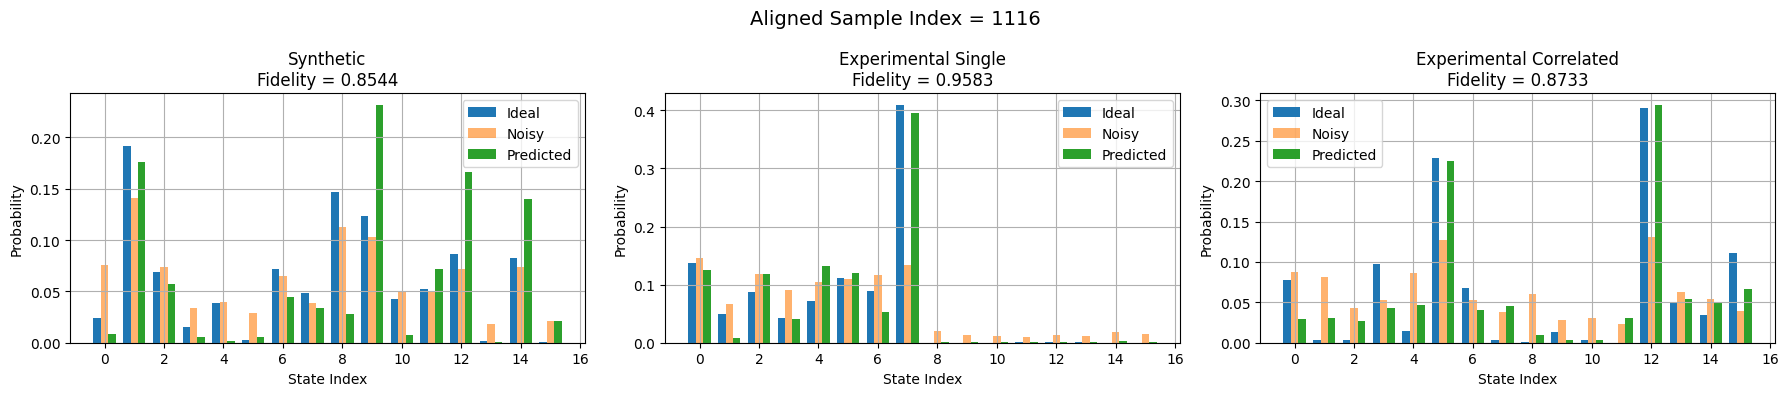

In [296]:
visualize_aligned_samples(model_phase3_2,
    X_test_syn_32, Y_test_syn_32,
    X_test_single_32, Y_test_single_32,
    X_test_corr_32, Y_test_corr_32,
    n_samples=1)

### Oganize outputs

In [297]:
test_sets_1 = {"synthetic":(X_test_syn_1, Y_test_syn_1),
    "experimental_single":(X_test_single_1, Y_test_single_1),
    "experimental_correlated": (X_test_corr_1, Y_test_corr_1)}
test_sets_2_0 = test_sets_1   # here test sets are same as above
test_sets_2_1 = test_sets_1   # same datasets

test_sets_3_0 = {"synthetic": (X_test_syn_30, Y_test_syn_30),
    "experimental_single": (X_test_single_30, Y_test_single_30),
    "experimental_correlated":(X_test_corr_30, Y_test_corr_30)}
test_sets_3_1 = {"synthetic":(X_test_syn_31, Y_test_syn_31),
    "experimental_single":(X_test_single_31, Y_test_single_31),
    "experimental_correlated": (X_test_corr_31, Y_test_corr_31)}
test_sets_3_2 = {"synthetic": (X_test_syn_32, Y_test_syn_32),
    "experimental_single":(X_test_single_32, Y_test_single_32),
    "experimental_correlated":(X_test_corr_32, Y_test_corr_32)}

In [298]:
from src.evaluation import run_all_tests
from src.registery import EXPERIMENTS
run_all_tests(model_base,
    EXPERIMENTS,
    circuit="Independent",
    training_noise="No Training",
    test_sets=test_sets_1)

run_all_tests(model_base_zz,
    EXPERIMENTS,
    circuit="ZZ FeatureMap",
    training_noise="No Training",
    test_sets=test_sets_3_0)

run_all_tests(model_phase1,
    EXPERIMENTS, circuit="Independent",
    training_noise="Synthetic", test_sets=test_sets_1)
run_all_tests(model_phase2_0,
    EXPERIMENTS,
    circuit="Independent",
    training_noise="Experimental Single",
    test_sets=test_sets_2_0 )
run_all_tests(model_phase2_1,
    EXPERIMENTS,
    circuit="Independent",
    training_noise="Experimental Correlated",
    test_sets=test_sets_2_0 )
run_all_tests(model_phase3_0,
    EXPERIMENTS,
    circuit="ZZ FeatureMap",
    training_noise="Synthetic",
    test_sets=test_sets_3_0 )
run_all_tests(model_phase3_1,
    EXPERIMENTS,
    circuit="ZZ FeatureMap",
    training_noise="Experimental Single",
    test_sets=test_sets_3_1 )
run_all_tests(model_phase3_2,
    EXPERIMENTS,
    circuit="ZZ FeatureMap",
    training_noise="Experimental Correlated",
    test_sets=test_sets_3_2 )

In [299]:
summary_df = build_summary_df(EXPERIMENTS)

# ترتیب ثابت سطرها (مدار × شرط آموزش)
summary_df = summary_df.reindex([
    ("Independent", "No Training"),
    ("Independent", "Synthetic"),
    ("Independent", "Experimental Single"),
    ("Independent", "Experimental Correlated"),
    ("ZZ FeatureMap", "No Training"),
    ("ZZ FeatureMap", "Synthetic"),
    ("ZZ FeatureMap", "Experimental Single"),
    ("ZZ FeatureMap", "Experimental Correlated"),])

# جدول خلاصه برای هر سه معیار (همه از یک summary_df، بدون بازاجرا)
# show_all_summary_tables(summary_df)
# نمایش تک‌معیاری دلخواه:
show_summary_table(summary_df, "FidelityMean")
# show_summary_table(summary_df, "L1Mean")
# show_summary_table(summary_df, "KLMean")

                                       Synthetic  Experimental Single  Experimental Correlated
Circuit       Training Noise                                                                  
Independent   No Training                  0.907                0.768                    0.763
              Synthetic                    0.979                0.836                    0.828
              Experimental Single          0.862                0.969                    0.988
              Experimental Correlated      0.866                0.965                    0.980
ZZ FeatureMap No Training                  0.938                0.853                    0.861
              Synthetic                    0.973                0.892                    0.902
              Experimental Single          0.883                0.942                    0.950
              Experimental Correlated      0.806                0.923                    0.980


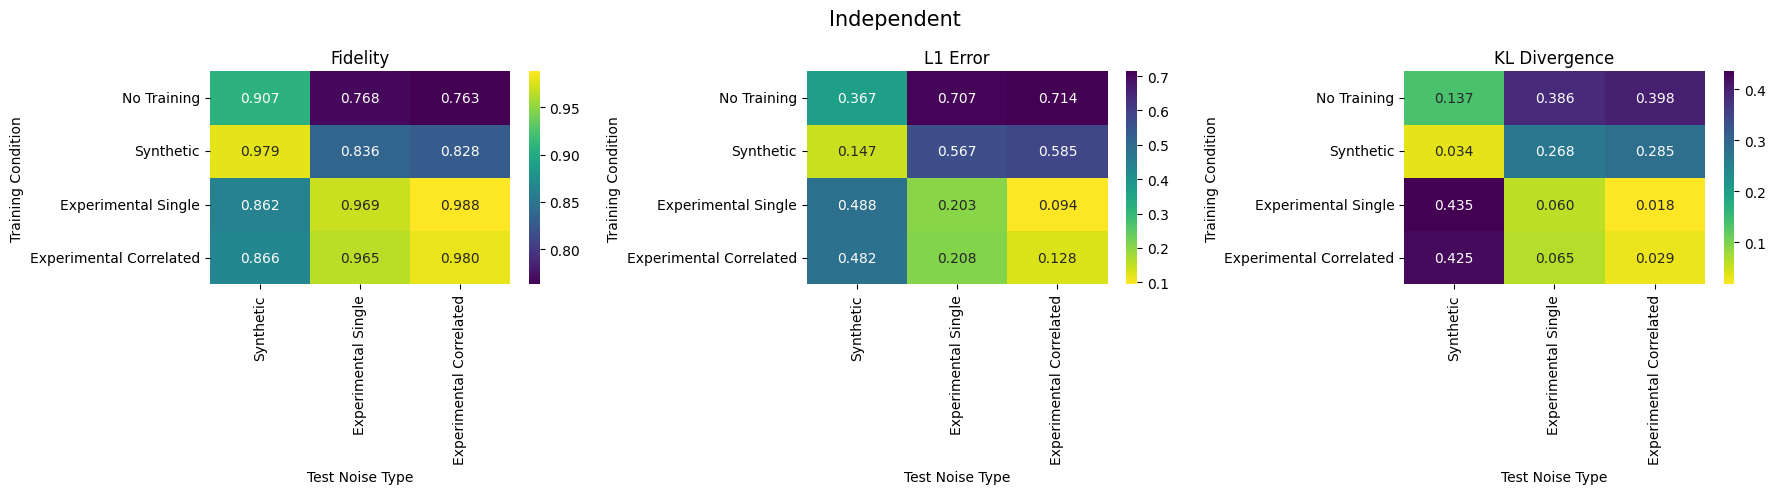

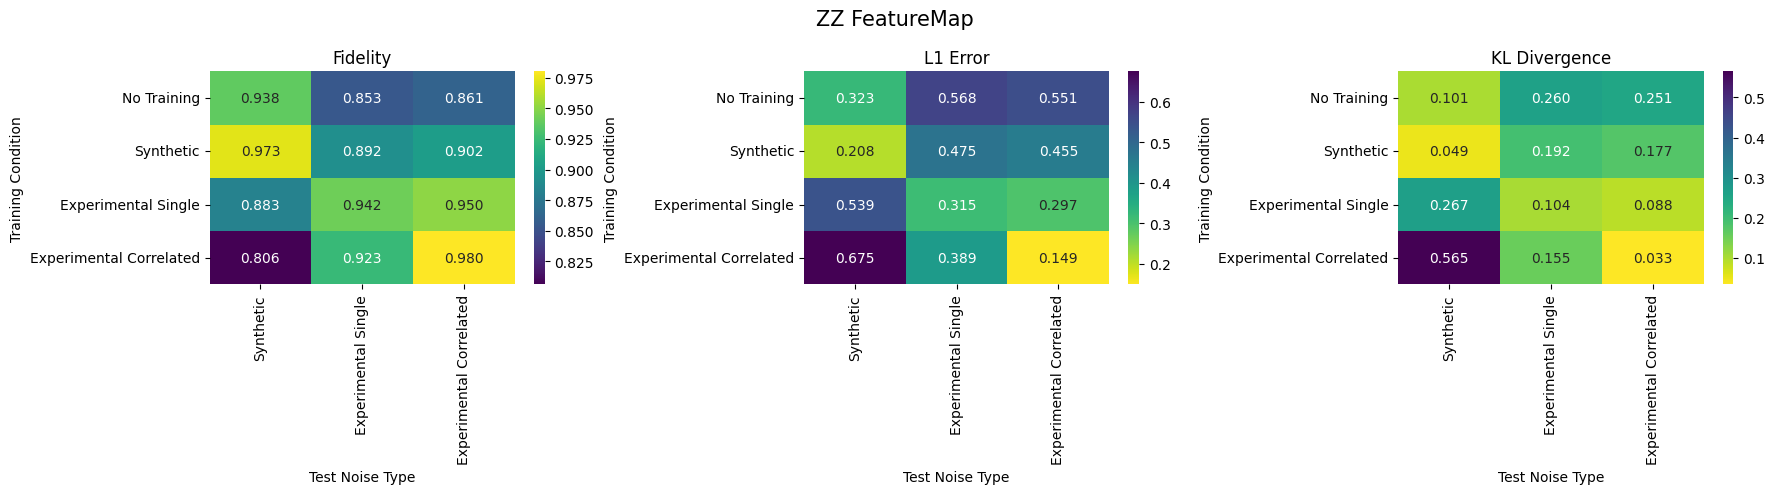

In [300]:
from src.dashboard import metrics_dashboard
# داشبورد ترکیبی: هر سه معیار کنار هم برای هر مدار
metrics_dashboard(summary_df)

# داشبورد تک‌معیاری (در صورت نیاز به نمای بزرگ‌تر هر معیار):
# full_dashboard(summary_df, metric="FidelityMean")
# full_dashboard(summary_df, metric="L1Mean")
# full_dashboard(summary_df, metric="KLMean")

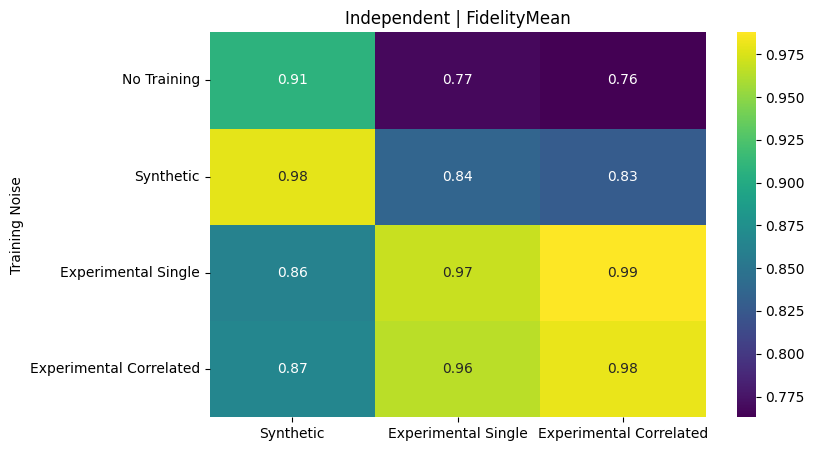

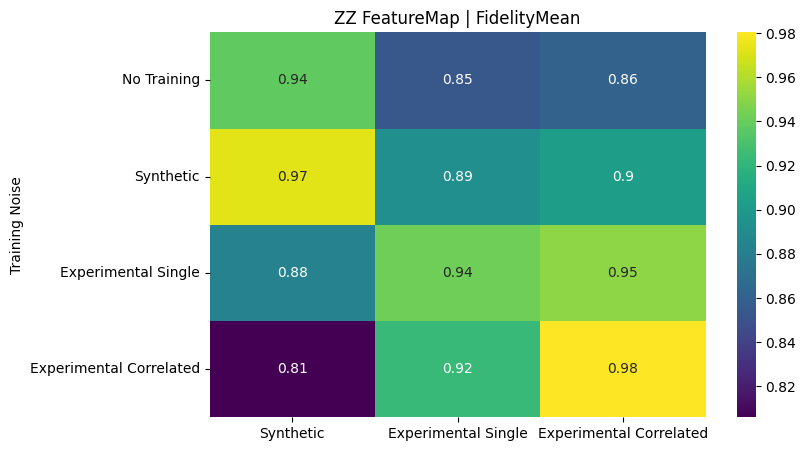

In [301]:
full_dashboard(summary_df, metric="FidelityMean")

##### Display results

In [ ]:
df_zz_raw = pd.DataFrame({
    "Dataset": [
        "synthetic",
        "experimental_single",
        "experimental_correlated"],
    "FidelityMean": [
        np.mean([
            fidelity(Y_test_syn_32[i], X_test_syn_32[i])
            for i in range(len(X_test_syn_32))]),
        np.mean([
            fidelity(Y_test_single_32[i], X_test_single_32[i])
            for i in range(len(X_test_single_32))]),
        np.mean([
            fidelity(Y_test_corr_32[i], X_test_corr_32[i])
            for i in range(len(X_test_corr_32))]) ]})

In [ ]:
import pandas as pd

phases = {
    ("Independent", "No Training"): df_0,
    ("Independent", "Synthetic"): df_1,
    ("Independent", "Experimental Single"): df_2_0,
    ("Independent", "Experimental Correlated"): df_2_1,
    ("ZZ FeatureMap", "No Training"): df_zz_raw,
    ("ZZ FeatureMap", "Synthetic"): df_3_0,
    ("ZZ FeatureMap", "Experimental Single"): df_3_1,
    ("ZZ FeatureMap", "Experimental Correlated"): df_3_2,}
rows = []
for (circuit, training_noise), df in phases.items():
    row = {"Circuit": circuit,"Training Noise": training_noise }
    for _, r in df.iterrows():
        dataset = r["Dataset"]
        if dataset == "synthetic":
            row["Synthetic"] = r["FidelityMean"]
        elif dataset == "experimental_single":
            row["Experimental Single"] = r["FidelityMean"]
        elif dataset == "experimental_correlated":
            row["Experimental Correlated"] = r["FidelityMean"]
    rows.append(row)
summary_df = pd.DataFrame(rows)
summary_df = summary_df[["Circuit","Training Noise",
    "Synthetic","Experimental Single",
    "Experimental Correlated" ]]
summary_df = summary_df.set_index(["Circuit", "Training Noise"])
print(summary_df.round(3).to_string())

In [ ]:
import numpy as np
def compute_metrics(preds, Y):
    fidelities = []
    l1s = []
    kls = []
    for i in range(len(preds)):
        p = preds[i]
        y = Y[i]
        # Fidelity
        fid = (np.sum(np.sqrt(p * y))) ** 2
        # L1 distance
        l1 = np.sum(np.abs(p - y))
        # KL divergence (safe version)
        kl = np.sum(
            y * np.log((y + 1e-10) / (p + 1e-10)) )
        fidelities.append(fid)
        l1s.append(l1)
        kls.append(kl)
    return {
        "FidelityMean": float(np.mean(fidelities)),
        "L1Mean": float(np.mean(l1s)),
        "KLMean": float(np.mean(kls)),
        # "FidelityStd": float(np.std(fidelities)),
        # "L1Std": float(np.std(l1s)),
        # "KLStd": float(np.std(kls)),
    }

In [ ]:
results_0 = {}
for noise_mode in noise_modes:
    X_test, Y_test, TH_test = load_dataset(
        split="test",
        circuit_type="independent",
        noise_mode=noise_mode )
    preds = model_base(X_test)  # یا batch inference
    results_0[noise_mode] = compute_metrics(preds, Y_test)
rows = []
for noise_mode, metrics in results_0.items():
    rows.append({
        "Dataset": noise_mode,
        **metrics})
df_0 = pd.DataFrame(rows)
df_0

### Generate and Save datasets

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="synthetic")
# about 17 min

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_single")
# Next
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
# done
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single")

In [ ]:
# TEST:
#     independent + experimental_single
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="experimental_single")

In [ ]:
# Test 1
X_test_base, Y_test_base, TH_test_base = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="synthetic")

In [ ]:
# Test Done!
X_test_fmap, Y_test_fmap, TH_test_fmap = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 1,"entanglement": "full"})

In [ ]:
# VALIDATION: Done!
#     independent + experimental_correlated
X_val2, Y_val2, TH_val2 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
# test Done!
# independent + experimental_correlated
X_test_B, Y_test_B, TH_test_B = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
# VALIDATION:
#     independent + experimental_single
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="independent",
    noise_mode="synthetic")

In [ ]:
#  Done!
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# Done 
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# here
X_va1, Y_va1, TH_va1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# here
X_1, Y_1, TH_1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# Generate diverse data set for zz_featuremap
# by parameters reps and theta range ---> reps: 1, 2 and theta range: [0, pi], [0, 2pi]

In [ ]:
X_test_corr, Y_test_corr, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)

purity_zz = np.mean([np.sum(y2**2) for y2 in Y_test_corr])
print("purity_zz",purity_zz)

In [ ]:
# reps= 2 and theta range: [0, pi/4]
X_test_fmap, Y_test_fmap, TH_test_fmap = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
X_test_corr2, Y_test_corr2, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)

purity_zz2 = np.mean([np.sum(y3**2) for y3 in Y_test_corr2])
print("purity_zz2",purity_zz2)

In [ ]:
X_test_corr, Y_test_corr, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
raw_fidelity = np.mean([
    fidelity(Y_test_corr[i], X_test_corr[i])
    for i in range(len(X_test_corr))])
print(raw_fidelity)

##### Save datasetsm